# 🧭 The Navigation Course: Temporal Catch Analysis

### Module 1 of the SquidStock Analytics Series

**Objective:** Conduct exploratory analysis of raw squid catch (tons) and associated environmental variables from **2000–2020** to uncover key temporal trends, seasonal variability, and ecological patterns.

> This notebook is the **first step in the SquidStock analytics pipeline**. It provides a data-driven foundation for understanding the structure, distribution, and temporal dynamics of the raw dataset before any formal statistical modeling or CPUE standardization is applied.

---

### 🎯 Scope & Analysis Overview

This module focuses on **exploratory data analysis (EDA)** to highlight meaningful patterns and guide subsequent modeling:

- Visual exploration of **monthly and yearly catch trends**
- Identification of **seasonal peaks** and variability in fishing effort
- Distribution and summary statistics of **catch data**
- Temporal trends of key **environmental drivers** (e.g., temperature, fishing depth)  
  > *Note: Chlorophyll-a and Sea Surface Height were not included as they were absent in the original raw dataset.*
- Trend direction indicators (↑ ↓ →) to summarize inter-annual changes
- Hypothesis-forming insights to inform **future modeling** and CPUE standardization

---

### 📊 Key Outputs

- Interactive and static **monthly catch plots**
- Yearly summary tables with **trend arrows** for environmental and catch features
- Exported visualizations and tabular summaries suitable for **reports and stakeholder briefings**

---

### 🌍 Value & Use Cases

By clearly visualizing raw trends and environmental co-variation, this notebook enables:

- Fisheries scientists to understand **baseline patterns** before formal CPUE standardization
- Marine managers to identify **seasonal shifts or potential early warning signals**
- Sustainability teams to integrate **long-term ecological indicators** into reporting

> **Strategic takeaway:** Understanding raw temporal dynamics ensures that subsequent models and management decisions are **rooted in data, not assumptions**.

In [1]:
# ============================
# Loading libraries
# ============================

import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import os

## Load and Prepare Dataset
We imported the preprocessed dataset with added columns from remote sensing data (SSH and Chlorophyll_a) but will NOT be using this colums in this first module (SSH and Chlorophyll_a) but solely focus on the original raw data.


In [2]:
# ============================
# Loading and preparing datasets
# ============================

df = pd.read_csv("../data/Final_dataset.csv")
df.columns = df.columns.str.strip()  # Clean column names

In [3]:

# Rename and create datetime
df.rename(columns={"Year1": "Year"}, inplace=True)
df["Date"] = pd.to_datetime(df[["Year", "Month", "Day"]])

## 📊 Monthly Catch Trends

Here we aggregate squid catch by month and year, convert to tons, and visualize trends across years.

In [4]:
# ============================
# Monthly Catch by Year (Aggregation)
# ============================

# Group by Year-Month
monthly_catch = (
    df.groupby(["Year", "Month"])
    .agg(
        TotalCatch=("SqCatch_Kg", "sum"),
        DaysFished=("Day", "count"),
        mean_Temp=("WaterTemp", "mean"),
        mean_Depth=("Depth", "mean")
    )
    .reset_index()
)

# Group by Year-Month
monthly_catch["Monthly_Catch_tons"] = monthly_catch["TotalCatch"] / 1000

# Group by Year-Month
monthly_catch.sort_values(["Year", "Month"], inplace=True)

# Export summary
summary = monthly_catch.groupby("Year")["Monthly_Catch_tons"].describe()
summary.to_csv("../results/summaries/yearly_catch_summary.csv")
print(monthly_catch.head())

   Year  Month    TotalCatch  DaysFished  mean_Temp  mean_Depth  \
0  2000      1  2.648377e+07        2208  13.668258   76.641709   
1  2000      2  6.532798e+07        2803  13.237296   78.006577   
2  2000      3  7.424052e+07        3024  12.107456   84.641644   
3  2000      4  3.705659e+07        2932  10.106503   96.687810   
4  2000      5  2.593114e+07        2862   8.798140  107.336254   

   Monthly_Catch_tons  
0        26483.767675  
1        65327.981802  
2        74240.523471  
3        37056.593858  
4        25931.139276  


### 📈 Monthly Catch by Year

Below we plot monthly catch across years to examine seasonal and interannual variation. 
- **Interactive** plot allows hovering and zoom
- **Static PDF** is exported for reproducibility

In [5]:
# ============================
# Monthly Catch by Year (Interactive)
# ============================

# Interactive Plot
fig = px.line(
    monthly_catch,
    x="Month",
    y="Monthly_Catch_tons",
    color="Year",
    markers=True,
    title="Monthly Catch (tons) by Year",
    labels={"Monthly_Catch": "(tons)", "Month": "Month"}
)

fig.update_layout(
    legend_title="Year",
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    hovermode='x unified',
    width=900,
    height=600
)

fig.write_html("../results/plots/monthly_catch_plot.html")
fig.show()


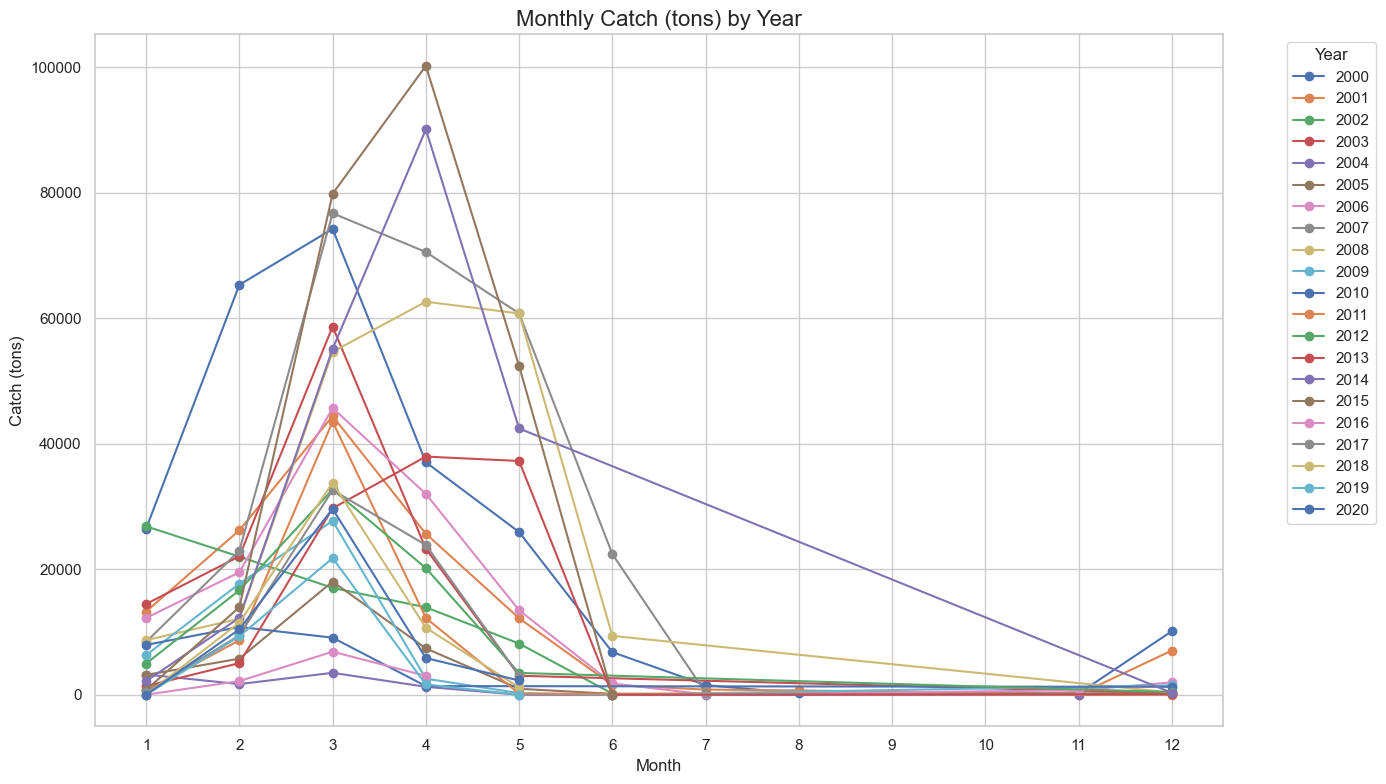

In [7]:

# ============================
# Monthly Catch by Year (Static)
# ============================

# Static Plot
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

for year in monthly_catch["Year"].unique():
    data = monthly_catch[monthly_catch["Year"] == year]
    plt.plot(data["Month"], data["Monthly_Catch_tons"], label=year, marker="o")

plt.title("Monthly Catch (tons) by Year", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Catch (tons)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/plots/monthly_catch_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("../results/plots/monthly_catch_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


## Monthly Catch Patterns by Year

Monthly trends in catches **consistent seasonal timing** but **variable catch intensity**:

- **📆 Seasonal Peak (Mar–May):** Most years show clear catch peaks in spring, aligning with known migration and spawning periods.

- **📉 Declining Peak Intensity:** Post-2015, peak catch values **drop notably**, despite similar seasonal timing — indicating fewer or less accessible squid.

- **🧭 Biological Consistency:** The persistent seasonal structure confirms a **biological driver** of catch timing, not effort alone.

---

## 🌡️ Yearly Environmental Feature Trends

The table below summarizes mean, standard deviation, and min/max of environmental drivers (e.g., water temperature, depth) across years.  
Arrows indicate **year-over-year trends** for each feature.

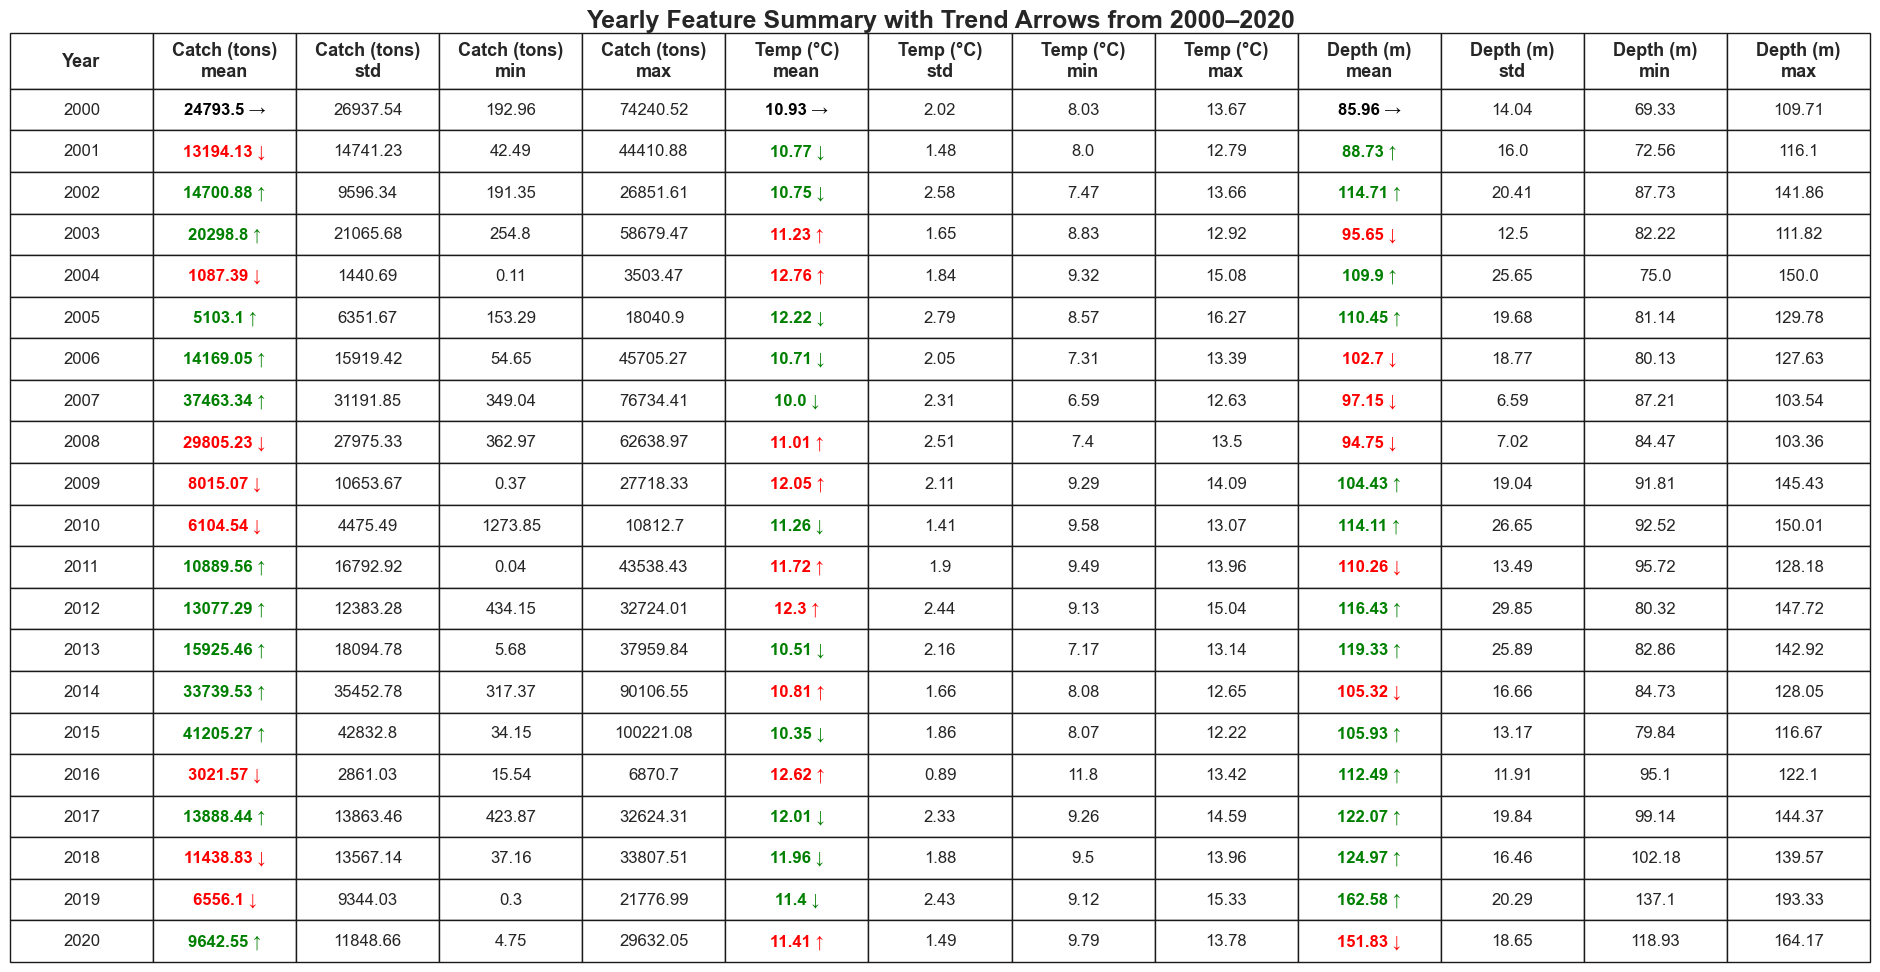

In [10]:
# ============================
# Yearly Feature Summary
# ============================

# --- Step 1: Compute grouped statistics ---
cols_to_agg = ['Monthly_Catch_tons', 'mean_Temp', 'mean_Depth']
grouped_stats = monthly_catch.groupby('Year')[cols_to_agg].agg(['mean', 'std', 'min', 'max'])
grouped_stats = grouped_stats.round(2)
grouped_stats.columns = ['_'.join(col).strip() for col in grouped_stats.columns.values]
grouped_stats.reset_index(inplace=True)

# --- Step 2: Add trend arrows to mean columns ---
numeric_features = ['Monthly_Catch_tons', 'mean_Temp', 'mean_Depth']
for feature in numeric_features:
    col = f"{feature}_mean"
    arrows = ['→']
    for i in range(1, len(grouped_stats)):
        prev = grouped_stats.loc[i - 1, col]
        curr = grouped_stats.loc[i, col]
        if curr > prev:
            arrows.append('↑')
        elif curr < prev:
            arrows.append('↓')
        else:
            arrows.append('→')
    grouped_stats[col] = grouped_stats[col].round(3).astype(str) + " " + arrows

# --- Step 3: Round other stats consistently ---
for feature in numeric_features:
    for stat in ['std', 'min', 'max']:
        col = f"{feature}_{stat}"
        if stat == 'std' or (stat == 'mean' and feature == 'SSH'):
            grouped_stats[col] = grouped_stats[col].round(4)
        else:
            grouped_stats[col] = grouped_stats[col].round(3)

# --- Step 4: Custom display names for table column headers ---
display_name_map = {
    'Monthly_Catch_tons': 'Catch (tons)',
    'mean_Temp': 'Temp (°C)',
    'mean_Depth': 'Depth (m)'
}

def split_colname(name):
    parts = name.rsplit('_', 1)  # Split once from the right
    if len(parts) == 2:
        feature, stat = parts
    else:
        feature = name
        stat = ''
    display_feature = display_name_map.get(feature, feature)
    return f"{display_feature}\n{stat}" if stat else display_feature

stacked_col_labels = [split_colname(col) for col in grouped_stats.columns]

# --- Step 5: Plot the summary table ---
fig, ax = plt.subplots(figsize=(24, 12))
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=grouped_stats.values,
    colLabels=stacked_col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)

for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(weight='bold', fontsize=13)
        cell.set_height(0.06)
    else:
        cell.set_height(0.045)

plt.title("Yearly Feature Summary with Trend Arrows from 2000–2020", fontsize=18, weight='bold')

# --- Step 6: Color the arrows ---
arrow_color_rules = {
    'mean_Temp':     {'↑': 'red', '↓': 'green', '→': 'black'},
    'Monthly_Catch_tons':  {'↑': 'green', '↓': 'red', '→': 'black'},
    'mean_Depth':         {'↑': 'green', '↓': 'red', '→': 'black'}
}

for col_idx, col_name in enumerate(grouped_stats.columns):
    for feature, colors in arrow_color_rules.items():
        if col_name == f"{feature}_mean":
            for row_idx in range(1, len(grouped_stats) + 1):  # Skip header
                cell = table[row_idx, col_idx]
                text = cell.get_text().get_text()
                arrow = text[-1]  # Last char is the arrow
                color = colors.get(arrow, 'black')
                cell.get_text().set_color(color)
                cell.get_text().set_fontweight('bold')

# --- Step 7: Save and show ---
plt.savefig("../outputs/yearly_feature_summary.png", dpi=300, bbox_inches='tight')
plt.savefig("../outputs/yearly_feature_summary.pdf", dpi=300, bbox_inches='tight')
plt.show()


### 📊 Yearly Environmental Feature Trends (2000–2020)

An analysis of environmental variables over two decades reveals **long-term oceanographic shifts** that closely align with the **observed decline in Catch rates**:

- **📉 Catch Decline:** While interannual peaks exist, mean catch generally **declines post-2015**, indicating potential stock stress or environmental displacement.

- **🌡️ Rising Water Temperature:** A steady increase in average water temperature suggests squid may be **migrating to cooler or deeper areas**, reducing their availability to the fleet.

- **⏬ Deepening Fishing Depths:** A clear trend toward deeper average fishing depths supports the hypothesis of **vertical migration** as squid adjust to warming surface layers.

---

🧭 *Next:* The following section will explore how these environmental trends relate to CPUE standardization and predictions, providing possible explanations for observed catch variability.

---

## ✅ Summary

- Monthly catch trends highlight seasonal peaks and interannual variability.
- Environmental variables show consistent directional trends over time, potentially linked to biomass changes.
- Visual outputs and tables are exported for further analysis and app integration.

This notebook forms the **exploratory foundation** for modeling and dashboard deployment in later modules.